In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.svm import SVC

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('diabetes.csv')

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# DiabetesPedigreeFunction -> Genetic risk score based on family history of diabetes.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
df['Insulin'].value_counts()

Insulin
0      374
105     11
130      9
140      9
120      8
      ... 
178      1
127      1
510      1
16       1
112      1
Name: count, Length: 186, dtype: int64

In [9]:
# The 0 values in the Insulin column represent missing data (NaN) and must be imputed prior to analysis.

In [10]:
df['BloodPressure'].value_counts()

BloodPressure
70     57
74     52
78     45
68     45
72     44
64     43
80     40
76     39
60     37
0      35
62     34
66     30
82     30
88     25
84     23
90     22
86     21
58     21
50     13
56     12
54     11
52     11
92      8
75      8
65      7
85      6
94      6
48      5
44      4
96      4
110     3
106     3
100     3
98      3
30      2
46      2
55      2
104     2
108     2
40      1
122     1
95      1
102     1
61      1
24      1
38      1
114     1
Name: count, dtype: int64

In [11]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [12]:
df_columns_to_check = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in df_columns_to_check:
    zero_count = (df[col] == 0).sum()
    zero_percentage = 100 * zero_count / len(df)
    print(f"{col}: {zero_count} - %{zero_percentage:.2f}")

Glucose: 5 - %0.65
BloodPressure: 35 - %4.56
SkinThickness: 227 - %29.56
Insulin: 374 - %48.70
BMI: 11 - %1.43


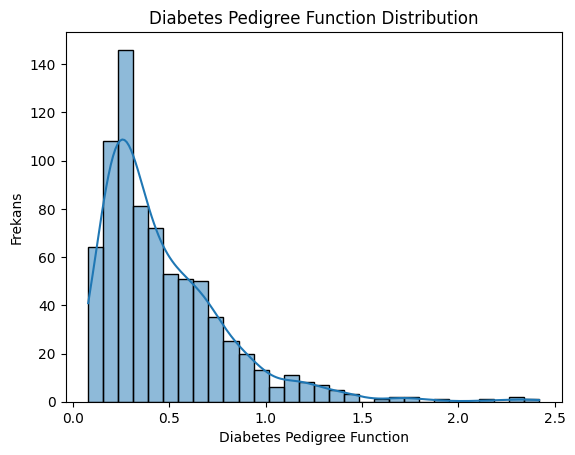

In [13]:
sns.histplot(df['DiabetesPedigreeFunction'], bins=30, kde=True)
plt.title('Diabetes Pedigree Function Distribution')
plt.xlabel('Diabetes Pedigree Function')
plt.ylabel('Frekans')
plt.show()

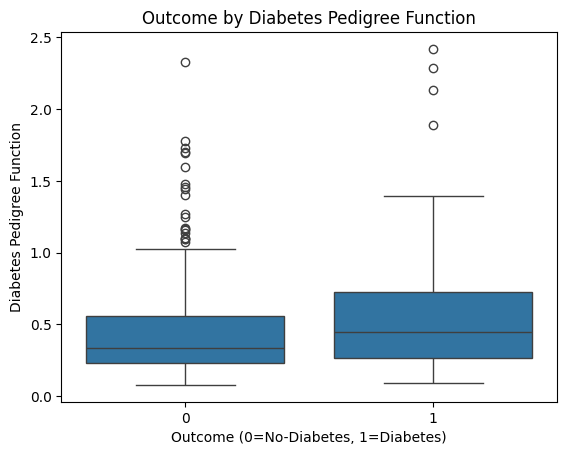

In [14]:
sns.boxplot(x='Outcome', y='DiabetesPedigreeFunction', data=df)
plt.title('Outcome by Diabetes Pedigree Function')
plt.xlabel('Outcome (0=No-Diabetes, 1=Diabetes)')
plt.ylabel('Diabetes Pedigree Function')
plt.show()

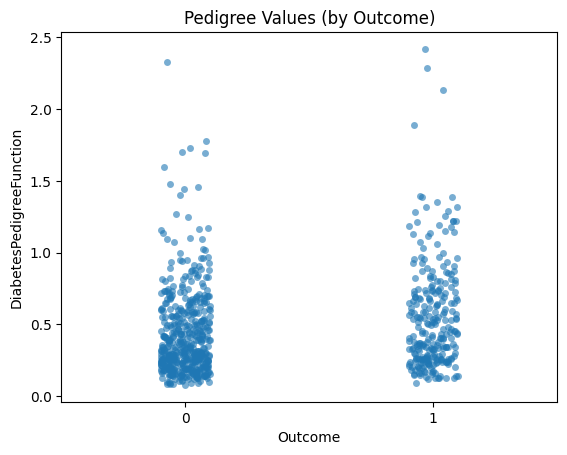

In [15]:
sns.stripplot(x='Outcome', y='DiabetesPedigreeFunction', data=df, jitter=True, alpha=0.6)
plt.title('Pedigree Values (by Outcome)')
plt.show()

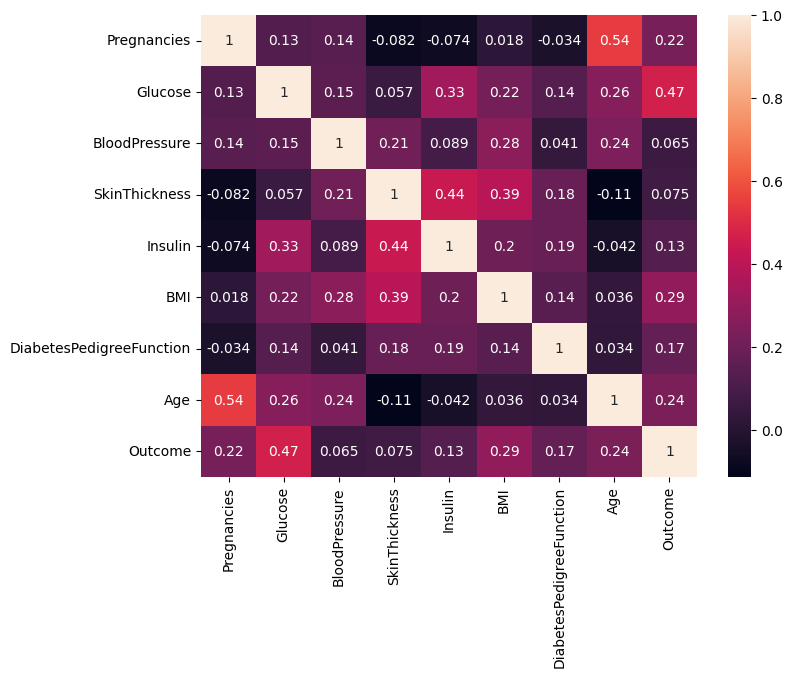

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [17]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [19]:
df_columns_to_fill = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [20]:
medians = {}
for col in df_columns_to_fill:
   median_value = X_train[X_train[col] != 0][col].median()
   medians[col] = median_value
   X_train[col] = X_train[col].replace(0, median_value)

for col in df_columns_to_fill:
   X_test[col] = X_test[col].replace(0, medians[col])

In [21]:
X_train.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,3.742671,121.815961,72.229642,28.568404,138.115635,32.348208,0.469168,32.907166
std,3.313264,30.104012,12.099278,8.410029,88.650282,6.935618,0.336847,11.503437
min,0.000000,44.000000,24.000000,8.000000,14.000000,18.200000,0.078000,21.000000
25%,1.000000,100.000000,64.000000,24.000000,116.000000,27.325000,0.241500,24.000000
50%,3.000000,118.000000,72.000000,28.500000,120.000000,32.000000,0.372500,29.000000
75%,6.000000,139.000000,80.000000,32.000000,129.750000,36.375000,0.613750,40.000000
max,17.000000,199.000000,122.000000,63.000000,846.000000,67.100000,2.420000,81.000000


In [22]:
X_test.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000
mean,4.253247,121.051948,73.012987,30.522727,138.720779,32.860390,0.482675,34.571429
std,3.567394,31.825873,12.105196,10.070234,79.592713,6.635854,0.309155,12.685155
min,0.000000,62.000000,48.000000,7.000000,15.000000,18.400000,0.102000,21.000000
25%,1.250000,96.000000,64.250000,28.000000,120.000000,28.425000,0.247250,24.000000
50%,3.000000,112.000000,72.000000,28.500000,120.000000,32.850000,0.372500,29.500000
75%,7.000000,146.000000,78.000000,33.000000,125.750000,36.975000,0.679250,42.000000
max,13.000000,197.000000,114.000000,99.000000,579.000000,53.200000,1.390000,67.000000


In [23]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
models = {
    "AdaBoost Classifier" : AdaBoostClassifier(),
    "Logistic Regression" : LogisticRegression(),
    "Naive Bayes" : GaussianNB(),
    "KNN" : KNeighborsClassifier(),
    "Decision Tree" : DecisionTreeClassifier(),
    "Random Forest" : RandomForestClassifier(),
    "SVM" : SVC()
}

In [25]:
for name, model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    print(f"Model: {name}")
    print("------------------")
    print("accuracy_score: ", accuracy_score(y_test,y_pred))
    print(classification_report(y_test,y_pred))
    print(confusion_matrix(y_test,y_pred))

Model: AdaBoost Classifier
------------------
accuracy_score:  0.7532467532467533
              precision    recall  f1-score   support

           0       0.82      0.79      0.80        99
           1       0.64      0.69      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.74       154
weighted avg       0.76      0.75      0.76       154

[[78 21]
 [17 38]]
Model: Logistic Regression
------------------
accuracy_score:  0.7532467532467533
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154

[[82 17]
 [21 34]]
Model: Naive Bayes
------------------
accuracy_score:  0.7597402597402597
              precision    recall  f1-score   support

           0   

# Hyperparameter Tuning

In [26]:
ada_params = {
    'n_estimators': [50, 70, 100, 120, 150, 200],
    'learning_rate': [0.001, 0.01, 0.1, 1, 10]
}
log_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2', None],
    'solver': ['liblinear', 'saga', 'newton-cg', 'newton-cholesky', 'sag', 'lbfgs']
}
nb_params = {}
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['minkowski', 'euclidean', 'manhattan']
}
dt_params = {
    'criterion': ['gini', 'entropy', 'log-loss'],
    'max_depth': [1,2,3,4,5,15,None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'splitter' : ["best", "random"],
    'max_features': ["sqrt", "log2", None]
}
rf_params = {
    'n_estimators': [100,200,500,1000],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ["sqrt", "log2", 5,6,7,8]
}
svm_param = {
    'C': [0.1, 1, 10, 100, ],
    'kernel': ["rbf", "linear"],
    'gamma': ['scale', 'auto', 0.1, 0.01],
}

In [27]:
randomcv_models = [
    ("KNN", KNeighborsClassifier(), knn_params),
    ("Random Forest", RandomForestClassifier(), rf_params),
    ("AdaBoost Classifier", AdaBoostClassifier(), ada_params),
    ("Logistic Regression", LogisticRegression(), log_params),
    ("Naive Bayes", GaussianNB(), nb_params),
    ("Decision Tree", DecisionTreeClassifier(), dt_params),
    ("SVM", SVC(), svm_param)
]

In [28]:
for name, model, param in randomcv_models:
    randomcv = RandomizedSearchCV(estimator=model, param_distributions=param, cv=3, n_jobs=-1, n_iter=100)
    randomcv.fit(X_train,y_train)
    print("Best params for ", name, randomcv.best_params_)

Best params for  KNN {'weights': 'distance', 'n_neighbors': 11, 'metric': 'manhattan'}
Best params for  Random Forest {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10}
Best params for  AdaBoost Classifier {'n_estimators': 50, 'learning_rate': 1}
Best params for  Logistic Regression {'solver': 'saga', 'penalty': 'l1', 'C': 0.1}
Best params for  Naive Bayes {}
Best params for  Decision Tree {'splitter': 'best', 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 5, 'criterion': 'gini'}
Best params for  SVM {'kernel': 'linear', 'gamma': 'scale', 'C': 0.1}


In [29]:
tuned_model = {
    "AdaBoost Classifier" : AdaBoostClassifier(n_estimators=120, learning_rate=1),
    "Logistic Regression" : LogisticRegression(solver="lbfgs", penalty="l2", C=100),
    "Naive Bayes" : GaussianNB(),
    "KNN" : KNeighborsClassifier(weights="uniform", n_neighbors=9, metric="manhattan"),
    "Decision Tree" : DecisionTreeClassifier(splitter='random', min_samples_split=2, min_samples_leaf=1, max_depth=3, max_features=None, criterion="gini"),
    "Random Forest" : RandomForestClassifier(n_estimators= 100, min_samples_split= 10, min_samples_leaf=1, max_features=8, max_depth=10),
    "SVM" : SVC(kernel="linear", gamma="auto", C=0.1)
}

In [34]:
for i in range(len(list(tuned_model))):
    model = list(tuned_model.values())[i]
    model.fit(X_train,y_train)

    y_pred = model.predict(X_test) 

    print(list(models.values())[i])

    print("Accuracy Score: ", accuracy_score(y_test,y_pred))
    print(classification_report(y_test,y_pred))
    print(confusion_matrix(y_test,y_pred))
    print("------------------------------------")
    print("\n")

AdaBoostClassifier()
Accuracy Score:  0.7532467532467533
              precision    recall  f1-score   support

           0       0.82      0.79      0.80        99
           1       0.64      0.69      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.74       154
weighted avg       0.76      0.75      0.76       154

[[78 21]
 [17 38]]
------------------------------------


LogisticRegression()
Accuracy Score:  0.7532467532467533
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154

[[82 17]
 [21 34]]
------------------------------------


GaussianNB()
Accuracy Score:  0.7597402597402597
              precision    recall  f1-score   support

           0